##### Baseline Model — VICReg + Hamiltonian (Projector-Predictor Split)
##### Architecture:
- ESM → bilinear → MLP expander → z_raw (unconstrained)
- VICReg var/cov regularisers applied to z_raw (γ=1.0)
- L2 normalise z_raw → ê (unit sphere)
- Hamiltonian invariance H = -½ ê^T Z* ê applied to ê
- In the no-Boltz limit: Z* = identity block, H reduces to -1 - cos(ê_T, ê_PH)
- Early stopping on val_loss
- Scoring via Hamiltonian energy (lower H = stronger binding)


In [1]:
# list of changes mnade that I need to replicate across the otehr model notebooks:

# 1. changed loading the embeddings one by one to shard dataset
# 2. Changed the EmbeddingTripletDataset to load the embeddings from shards

In [2]:
# imports
import time
import esm
import pandas as pd
import torch
from torch import Tensor
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.nn.utils.rnn import pad_sequence
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import copy
from datetime import datetime

import sys
import os
import time
import math
import random
import pickle
import subprocess
import gc
from pathlib import Path
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display, update_display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ESM imports
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinTensor
from esm.models.esmc import _BatchedESMProteinTensor

# Tokenizer imports
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers import normalizers
from tokenizers.normalizers import NFD, Lowercase, StripAccents
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordPieceTrainer
from tokenizers import decoders

# PEFT imports
from peft import get_peft_model, LoraConfig, TaskType
from peft.tuners.lora import LoraConfig, LoraModel


# validation function imports
from collections import defaultdict

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

# Set environment variable
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Reproducibility seed (used for shard creation + training)
SEED = 31

def set_global_seed(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)


/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:

model_name = 'baseline_vicreg_hamiltonian'


In [4]:
# Get current working directory and create models folder
import os
from pathlib import Path

# Get the current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Get the project root (go up one level from scripts/train)
project_root = Path(current_dir).parent.parent
print(f"Project root: {project_root}")

# Create models directory in project root
models_dir = project_root / "models"
if not models_dir.exists():
    print(f"Models directory does not exist, creating it at: {models_dir}")
    models_dir.mkdir(exist_ok=True)
print(f"Models directory at: {models_dir}")

# Also create a checkpoints subdirectory for saving model checkpoints
checkpoints_dir = models_dir / "checkpoints"
if not checkpoints_dir.exists():
    print(f"Checkpoints directory does not exist, creating it at: {checkpoints_dir}")
    checkpoints_dir.mkdir(exist_ok=True)
print(f"Checkpoints directory at: {checkpoints_dir}")


embeddings_dir = models_dir / "embeddings"
if not embeddings_dir.exists():
    print(f"Embeddings directory does not exist, creating it at: {embeddings_dir}")
    embeddings_dir.mkdir(exist_ok=True)
print(f"Embeddings directory at: {embeddings_dir}")


figure_dir = models_dir / "figures"
if not figure_dir.exists():
    print(f"Figures directory does not exist, creating it at: {figure_dir}")
    figure_dir.mkdir(exist_ok=True)
print(f"Figures directory at: {figure_dir}")

FIGURE_SUBDIR = figure_dir / "baseline_vicreg_hamiltonian"
FIGURE_SUBDIR.mkdir(parents=True, exist_ok=True)
print(f"Figure subdirectory at: {FIGURE_SUBDIR}")


Current working directory: /home/natasha/multimodal_model/scripts/train
Project root: /home/natasha/multimodal_model
Models directory at: /home/natasha/multimodal_model/models
Checkpoints directory at: /home/natasha/multimodal_model/models/checkpoints
Embeddings directory at: /home/natasha/multimodal_model/models/embeddings
Figures directory at: /home/natasha/multimodal_model/models/figures
Figure subdirectory at: /home/natasha/multimodal_model/models/figures/baseline_vicreg_hamiltonian


##### Get ESM Embeddings

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Use original train file + new IMMREP-A val/test files.
# TRAIN_CSV = "/home/natasha/multimodal_model/data/train/train_df_clean.csv"
# VAL_CSV   = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg_A.csv"
# TEST_CSV  = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg_A.csv"

# Use original train file + new IMMREP-A val/test files.
#TRAIN_CSV = "/home/natasha/multimodal_model/data/train/train_df_clean.csv"
TRAIN_CSV = "/home/natasha/multimodal_model/data/train/train_multiview_balanced_full_hard_decoys.csv"
#VAL_CSV   = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_tulip_decoys_strict.csv"
VAL_CSV   = "/home/natasha/multimodal_model/data/val/val_multiview.csv"
#TEST_CSV  = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_tulip_decoys_strict.csv"
TEST_CSV  = "/home/natasha/multimodal_model/data/test/test_multiview.csv"
#TEST_CSV  = "/home/natasha/multimodal_model/data/test/immrep_test_set_pair_id.csv"

# Keep shards isolated from previous runs.
EMBED_ROOT = Path(embeddings_dir / "KNN_embeddings_dir")
EMBED_ROOT.mkdir(parents=True, exist_ok=True)

In [13]:
def load_split_sequences(
    csv_path,
    tcr_col="TCR_full",
    peptide_col="Peptide",
    hla_col="HLA_sequence",
    binding_col="binding_flag",
    pair_id_col="pair_id",
):
    df = pd.read_csv(csv_path).reset_index(drop=True)

    required = [tcr_col, peptide_col, hla_col, binding_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    tcrs_data = df[tcr_col].astype(str).tolist()
    peptides_data = df[peptide_col].astype(str).tolist()
    hlas_data = df[hla_col].astype(str).tolist()
    binding_flags = df[binding_col].astype(int).tolist()

    if pair_id_col in df.columns:
        pair_ids = df[pair_id_col].tolist()
    else:
        pair_ids = list(range(len(df)))

    return {
        "df": df,
        "tcrs_data": tcrs_data,
        "peptides_data": peptides_data,
        "hlas_data": hlas_data,
        "binding_flags": binding_flags,
        "pair_ids": pair_ids,
    }

In [14]:
train_split = load_split_sequences(TRAIN_CSV)

/tmp/ipykernel_2678101/4076233644.py:9: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path).reset_index(drop=True)


##### Mask Data and Collate for MLM for Encoders

In [15]:
# do for entire dataset
# do we also want to output attention_mask from the tokenizer?
model = ESMC.from_pretrained("esmc_300m").eval()

tok = model.tokenizer
CLS_ID = tok.cls_token_id
EOS_ID = tok.eos_token_id
PAD_ID = tok.pad_token_id
MASK_ID = tok.mask_token_id

AA_IDS =  [5,10,17,13,23,16,9,6,21,12,4,15,20,18,14,8,11,22,19,7]


class EncodedSeqDataset(Dataset):
    def __init__(self, sequences, enc):     # ← now takes two arguments
        self.sequences = sequences          # list[str]
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "sequence": self.sequences[idx],  # raw sequence string
            "input_ids": torch.as_tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.as_tensor(self.attention_mask[idx], dtype=torch.long),
        }


In [16]:
class MLMProteinCollator:
    def __init__(self, *, cls_id, eos_id, pad_id, mask_id, amino_acids,
                 p=0.15, min_per_seq=2, max_per_seq=45, aa_frac=0.20):
        self.CLS = cls_id
        self.EOS = eos_id
        self.PAD = pad_id
        self.MASK = mask_id
        self.aa = torch.as_tensor(amino_acids, dtype=torch.long)
        self.p = p
        self.min_per_seq = min_per_seq
        self.max_per_seq = max_per_seq
        self.aa_frac = aa_frac
        

    @torch.no_grad()
    def mask_batch(self, input_ids, attention_mask):
        device = input_ids.device
        aa = self.aa.to(device)

        B, L = input_ids.shape
        valid_mask = attention_mask.bool() \
                   & (input_ids != self.PAD) \
                   & (input_ids != self.CLS) \
                   & (input_ids != self.EOS)

        masked_input_ids = input_ids.clone()
        labels = torch.full_like(input_ids, -100)

        for i in range(B):
            vmask = valid_mask[i]
            if not vmask.any():
                continue

            valid_idx = vmask.nonzero(as_tuple=False).squeeze(1)  # (L_valid,)
            L_valid = valid_idx.numel()

            # how many to mask: floor(p*L_valid), clamped to [2, 45] but never > L_valid
            n = torch.floor(self.p * torch.tensor(L_valid, device=device, dtype=torch.float32)).to(torch.int64)
            n = torch.clamp(n, min=self.min_per_seq, max=min(self.max_per_seq, L_valid))
            if n.item() == 0:
                continue

            # choose n distinct valid positions
            chosen = valid_idx[torch.randperm(L_valid, device=device)[:n]]

            # split into AA vs MASK; ensure >=1 AA if n>=2
            n_amino = torch.floor(self.aa_frac * n).to(torch.int64)
            if n.item() >= 2:
                n_amino = torch.clamp(n_amino, min=1)
            n_mask = n - n_amino

            order = torch.randperm(n.item(), device=device)
            mask_pos  = chosen[order[:n_mask]]
            amino_pos = chosen[order[n_mask:]]

            # labels only at supervised positions
            labels[i, chosen] = input_ids[i, chosen]

            # apply edits
            if n_mask.item() > 0:
                masked_input_ids[i, mask_pos] = self.MASK
            if n_amino.item() > 0:
                r_idx = torch.randint(high=aa.numel(), size=(n_amino.item(),), device=device)
                masked_input_ids[i, amino_pos] = aa[r_idx]

        return masked_input_ids, labels


    def __call__(self, features):
        input_ids = torch.stack([f["input_ids"] for f in features], dim=0)
        attention_mask = torch.stack([f["attention_mask"] for f in features], dim=0)
        sequences = [f["sequence"] for f in features]
        proteins = [ESMProtein(sequence=f["sequence"]) for f in features]
        batched_clean = _BatchedESMProteinTensor(sequence=input_ids)


        masked_input_ids, labels = self.mask_batch(input_ids, attention_mask)

        # build masked sequences as strings (keep <mask>, drop CLS/EOS/PAD)
        masked_sequences = []
        for row in masked_input_ids.tolist():
            #toks = collator.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            toks = self.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            aa = []
            for t in toks:
                if t in (self.tokenizer.cls_token, self.tokenizer.eos_token, self.tokenizer.pad_token):
                #if t in (collator.tokenizer.cls_token, collator.tokenizer.eos_token, collator.tokenizer.pad_token):
                    continue
                aa.append(t)  # AA tokens are single letters; keep "<mask>" as is
            masked_sequences.append("".join(aa))

        proteins_masked = [ESMProtein(sequence=s) for s in masked_sequences]
        batched_masked = _BatchedESMProteinTensor(sequence=masked_input_ids)


        return {
            "masked_input_ids": masked_input_ids,
            "labels": labels,
            "attention_mask": attention_mask,
            "clean_input_ids": input_ids.clone(),
            "clean_sequences": sequences,                 # clean strings
            "masked_sequences": masked_sequences,   # masked strings  ← NEW
            "clean_sequences_ESMprotein": proteins,
            "masked_sequences_ESMprotein": proteins_masked,
            "masked_input_ids_ESMprotein_batched": batched_masked,
            "clean_input_ids_ESMprotein_batched": batched_clean,
        }

In [17]:
class CleanSeqDataset(Dataset):
    def __init__(self, sequences, tokenizer):
        self.sequences = sequences
        enc = tokenizer(sequences, return_tensors="pt", padding=True)
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
        }


def clean_collate(features):
    return {
        "input_ids": torch.stack([f["input_ids"] for f in features], dim=0),
        "attention_mask": torch.stack([f["attention_mask"] for f in features], dim=0),
    }

In [18]:
def build_modality_loaders(
    model,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    clean_tcrs_tokenized = model.tokenizer(tcrs_data, return_tensors="pt", padding=True)
    clean_peptides_tokenized = model.tokenizer(peptides_data, return_tensors="pt", padding=True)
    clean_hlas_tokenized = model.tokenizer(hlas_data, return_tensors="pt", padding=True)

    tcr_ds = EncodedSeqDataset(tcrs_data, clean_tcrs_tokenized)
    pep_ds = EncodedSeqDataset(peptides_data, clean_peptides_tokenized)
    hla_ds = EncodedSeqDataset(hlas_data, clean_hlas_tokenized)

    collator = MLMProteinCollator(
        cls_id=CLS_ID,
        eos_id=EOS_ID,
        pad_id=PAD_ID,
        mask_id=MASK_ID,
        amino_acids=AA_IDS,
        p=0.15,
        min_per_seq=2,
        max_per_seq=45,
        aa_frac=0.20,
    )
    collator.tokenizer = model.tokenizer

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)

    return tcr_loader, pep_loader, hla_loader

In [19]:
def build_clean_loaders(
    tokenizer,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    tcr_ds = CleanSeqDataset(tcrs_data, tokenizer)
    pep_ds = CleanSeqDataset(peptides_data, tokenizer)
    hla_ds = CleanSeqDataset(hlas_data, tokenizer)

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)

    return tcr_loader, pep_loader, hla_loader

In [20]:
#model = ESMC.from_pretrained("esmc_300m").eval()
#base = ESMC.from_pretrained("esmc_300m")

train_tcr_loader, train_pep_loader, train_hla_loader = build_modality_loaders(
    model=model,
    tcrs_data=train_split["tcrs_data"],
    peptides_data=train_split["peptides_data"],
    hlas_data=train_split["hlas_data"],
    batch_size=8,
    num_workers=4,
    shuffle=True,
)

# when we reload for train, test and val we will not shuffle

In [21]:
def optimizer_to_cpu(optim):
    for st in optim.state.values():
        for k, v in list(st.items()):
            if torch.is_tensor(v):
                st[k] = v.detach().to("cpu")

In [14]:
num_epochs = 3
base_tcr = ESMC.from_pretrained("esmc_300m")

use_amp = torch.cuda.is_available()

lora_cfg = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

model_tcr = LoraModel(base_tcr, lora_cfg, adapter_name="tcr")

for p in model_tcr.parameters():
    p.requires_grad = False
for name, p in model_tcr.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_tcr.to(device)
model_tcr.train()

optim_tcr = torch.optim.AdamW(
    (p for p in model_tcr.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01,
)

scaler = GradScaler(enabled=False)

epoch_losses = []

for epoch in range(num_epochs):
    model_tcr.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_tcr_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_tcr.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_tcr(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_tcr.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - TCR MLM loss: {avg_epoch_loss:.4f}")


optimizer_to_cpu(optim_tcr)

checkpoint_filename = "tcr_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "tcr_model_state_dict": model_tcr.state_dict(),
    "optimizer_state_dict": optim_tcr.state_dict(),
    "epoch_losses": epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_tcr.to("cpu")
del optim_tcr, model_tcr, checkpoint_dict
torch.cuda.empty_cache()


# took 6 minutes for 1 epochs on 31K pairs
# took 14 minutes for 3 epochs on 31K pairs

/tmp/ipykernel_2819272/2759862157.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - TCR MLM loss: 0.6116
Epoch 2/3 - TCR MLM loss: 0.3114
Epoch 3/3 - TCR MLM loss: 0.2554
Checkpoint saved to tcr_encoder_checkpoint.pth


In [15]:
# peptide encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_pep = ESMC.from_pretrained("esmc_300m")
model_pep = LoraModel(base_pep, lora_cfg, adapter_name="pep")

# freeze everything; unfreeze only LoRA params
for p in model_pep.parameters():
    p.requires_grad = False
for name, p in model_pep.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_pep.to(device)
model_pep.train()

optim_pep = torch.optim.AdamW(
    (p for p in model_pep.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

pep_epoch_losses = []

for epoch in range(num_epochs):
    model_pep.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_pep_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_pep.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_pep(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_pep.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    pep_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - peptide MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_pep)

checkpoint_filename = "peptide_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "peptide_model_state_dict": model_pep.state_dict(),
    "optimizer_state_dict": optim_pep.state_dict(),
    "epoch_losses": pep_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_pep.to("cpu")
del optim_pep, model_pep, checkpoint_dict
torch.cuda.empty_cache()

# took 6 mins for train dataset (31K pairs)

/tmp/ipykernel_2819272/2539404451.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - peptide MLM loss: 0.7035
Epoch 2/3 - peptide MLM loss: 0.3856
Epoch 3/3 - peptide MLM loss: 0.3432
Checkpoint saved to peptide_encoder_checkpoint.pth


In [16]:
# HLA encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_hla = ESMC.from_pretrained("esmc_300m")
model_hla = LoraModel(base_hla, lora_cfg, adapter_name="hla")

# freeze everything; unfreeze only LoRA params
for p in model_hla.parameters():
    p.requires_grad = False
for name, p in model_hla.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_hla.to(device)
model_hla.train()

optim_hla = torch.optim.AdamW(
    (p for p in model_hla.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

hla_epoch_losses = []

for epoch in range(num_epochs):
    model_hla.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_hla_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_hla.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_hla(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_hla.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    hla_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - HLA MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_hla)

checkpoint_filename = "hla_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "hla_model_state_dict": model_hla.state_dict(),
    "optimizer_state_dict": optim_hla.state_dict(),
    "epoch_losses": hla_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_hla.to("cpu")
del optim_hla, model_hla, checkpoint_dict
torch.cuda.empty_cache()

# took 21 mins for 3 epochs on 31K pairs

/tmp/ipykernel_2819272/2881670186.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - HLA MLM loss: 0.0312
Epoch 2/3 - HLA MLM loss: 0.0066
Epoch 3/3 - HLA MLM loss: 0.0042
Checkpoint saved to hla_encoder_checkpoint.pth


#### Load Encoders

a) Load encoders as fixed feature extractors

In [22]:
# reload everything you need (like dataloaders, model etc.), such that one can run the notebook from this point


In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [24]:
"""
LOADING ENCODERS FOR USE AS FIXED FEATURE EXTRACTORS

Use case: Use encoders as fixed/pre-trained components for the next part of the training pipeline (the non-contrastive loss with projection heads)

NEEDED:
✅ Model weights (to get the fine-tuned LoRA adapters)
✅ Set to .eval() mode (to disable dropout, use batch norm stats, etc.)

NOT NEEDED:
❌ Optimizer state - only needed if you were continuing to train the encoders

NOTE: The checkpoint contains 'optimizer_state_dict', but we're ignoring it
since we're using these models as frozen feature extractors.
"""

# Step 1: Load the checkpoint dictionaries (just Python dicts from disk)

checkpoint_tcr = torch.load(checkpoints_dir/'tcr_encoder_checkpoint.pth', map_location='cpu')
checkpoint_pep = torch.load(checkpoints_dir/'peptide_encoder_checkpoint.pth', map_location='cpu')
checkpoint_hla = torch.load(checkpoints_dir/'hla_encoder_checkpoint.pth', map_location='cpu')

# Step 2: Recreate the model architectures (same as during training)
lora_cfg = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

# Create models with same architecture as during training
tcr_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="tcr")
peptide_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="pep")
hla_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="hla")

# Step 3: Load the model state dictionaries (this loads base weights + LoRA adapters)
# Note: We're NOT loading optimizer_state_dict - not needed for inference/feature extraction
tcr_encoder.load_state_dict(checkpoint_tcr['tcr_model_state_dict'])
peptide_encoder.load_state_dict(checkpoint_pep['peptide_model_state_dict'])
hla_encoder.load_state_dict(checkpoint_hla['hla_model_state_dict'])

# Step 4: Set to evaluation mode and move to CPU
# .eval() mode ensures: no dropout, batch norm uses running stats, etc.


# Load to GPU becuase we need to get the embeddings in the forward pass
tcr_encoder.to(device).eval()
peptide_encoder.to(device).eval()
hla_encoder.to(device).eval()

print("✓ Encoders loaded successfully as fixed feature extractors!")
print("  (Optimizer state skipped - not needed for this use case)")



✓ Encoders loaded successfully as fixed feature extractors!
  (Optimizer state skipped - not needed for this use case)


b) Load Embeddings: Pre-compute embeddings so we don't have to do it at the forward step

In [25]:
# don't need to rerun

def save_embedding_shards_for_split(
    split_name,
    split_data,
    tokenizer,
    tcr_encoder,
    peptide_encoder,
    hla_encoder,
    save_root,
    device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
):
    split_dir = Path(save_root) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    tcr_loader, pep_loader, hla_loader = build_clean_loaders(
        tokenizer=tokenizer,
        tcrs_data=split_data["tcrs_data"],
        peptides_data=split_data["peptides_data"],
        hlas_data=split_data["hlas_data"],
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
    )

    chunk = []
    shard_id = 0

    binding_flags = split_data["binding_flags"]
    pair_ids = split_data["pair_ids"]
    pair_ptr = 0

    tcr_encoder.eval()
    peptide_encoder.eval()
    hla_encoder.eval()

    with torch.inference_mode():
        for i, (tcr_batch, pep_batch, hla_batch) in enumerate(zip(tcr_loader, pep_loader, hla_loader)):

            tcr_ids = tcr_batch["input_ids"].to(device, non_blocking=True)
            pep_ids = pep_batch["input_ids"].to(device, non_blocking=True)
            hla_ids = hla_batch["input_ids"].to(device, non_blocking=True)

            tcr_mask = tcr_batch["attention_mask"].to(torch.bool).cpu()
            pep_mask = pep_batch["attention_mask"].to(torch.bool).cpu()
            hla_mask = hla_batch["attention_mask"].to(torch.bool).cpu()

            emb_T = tcr_encoder(sequence_tokens=tcr_ids).embeddings.to(torch.float16).cpu()
            emb_P = peptide_encoder(sequence_tokens=pep_ids).embeddings.to(torch.float16).cpu()
            emb_H = hla_encoder(sequence_tokens=hla_ids).embeddings.to(torch.float16).cpu()

            B = emb_T.shape[0]

            batch_binding = binding_flags[pair_ptr:pair_ptr + B]
            batch_pair_ids = pair_ids[pair_ptr:pair_ptr + B]

            chunk.append({
                "emb_T": emb_T,
                "emb_P": emb_P,
                "emb_H": emb_H,
                "mask_T": tcr_mask,
                "mask_P": pep_mask,
                "mask_H": hla_mask,
                "binding_flag": torch.tensor(batch_binding, dtype=torch.long),
                "pair_id": batch_pair_ids,
                "batch_idx": i,
                "split": split_name,
            })

            pair_ptr += B

            del tcr_ids, pep_ids, hla_ids

            if torch.cuda.is_available() and (i % 50 == 0):
                torch.cuda.empty_cache()

            if len(chunk) >= chunk_size:
                torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
                shard_id += 1
                chunk.clear()
                gc.collect()

    if chunk:
        torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
        chunk.clear()
        gc.collect()

    print(f"{split_name}: saved {shard_id + 1} shard(s) to {split_dir}")

In [26]:
train_split = load_split_sequences(TRAIN_CSV)
val_split = load_split_sequences(VAL_CSV)
test_split = load_split_sequences(TEST_CSV)

# Build metadata lookups for cross-reactivity analysis
def build_peptide_lookup(df):
    lookup = {}
    for _, row in df.iterrows():
        pid = str(row.get("pair_id", row.name))
        pep = str(row["Peptide"])
        lookup[pid] = pep
    return lookup

def build_tcr_lookup(df):
    lookup = {}
    for _, row in df.iterrows():
        pid = str(row.get("pair_id", row.name))
        tcr = str(row["TCR_full"])
        lookup[pid] = tcr
    return lookup

def build_train_exposure_counts(df):
    pos = df[df["binding_flag"] == 1].copy() if "binding_flag" in df.columns else df.copy()
    pep_counts = pos["Peptide"].astype(str).value_counts().to_dict()
    tcr_counts = pos["TCR_full"].astype(str).value_counts().to_dict()
    return pep_counts, tcr_counts

pep_lookup_train = build_peptide_lookup(train_split["df"])
pep_lookup_val = build_peptide_lookup(val_split["df"])
pep_lookup_test = build_peptide_lookup(test_split["df"])

tcr_lookup_train = build_tcr_lookup(train_split["df"])
tcr_lookup_val = build_tcr_lookup(val_split["df"])
tcr_lookup_test = build_tcr_lookup(test_split["df"])

train_pep_counts, train_tcr_counts = build_train_exposure_counts(train_split["df"])

print(f"Peptide lookups: train={len(pep_lookup_train)}, val={len(pep_lookup_val)}, test={len(pep_lookup_test)}")
print(f"TCR lookups: train={len(tcr_lookup_train)}, val={len(tcr_lookup_val)}, test={len(tcr_lookup_test)}")

/tmp/ipykernel_2678101/4076233644.py:9: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path).reset_index(drop=True)


Peptide lookups: train=53856, val=3888, test=4364
TCR lookups: train=53856, val=3888, test=4364


In [27]:
# don't need to rerun

save_embedding_shards_for_split(
    split_name="train",
    split_data=train_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="val",
    split_data=val_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="test",
    split_data=test_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)


# creates directories below and saves like shard_00000.pt etc.
# /home/natasha/multimodal_model/models/embeddings/no_boltz_train_dedup/train/
# /home/natasha/multimodal_model/models/embeddings/no_boltz_train_dedup/val/
# /home/natasha/multimodal_model/models/embeddings/no_boltz_train_dedup/test/

train: saved 68 shard(s) to /home/natasha/multimodal_model/models/embeddings/KNN_embeddings_dir/train
val: saved 5 shard(s) to /home/natasha/multimodal_model/models/embeddings/KNN_embeddings_dir/val
test: saved 6 shard(s) to /home/natasha/multimodal_model/models/embeddings/KNN_embeddings_dir/test


#### Loss Function and Training

a) Projection heads

In [55]:
# Projected Encoder to get z_T and z_pMHC
# Bilinear factored compression: z = vec(A^T X B) @ H
# Then MLP expander for nonlinear capacity (VICReg-style)
#
# Architecture:
#   1. Channel compression: (B, L, D) @ B_c -> (B, L, rD)
#   2. Positional compression: A_c^T @ Y -> (B, rL, rD)
#   3. Flatten + linear map: (rL*rD) @ H_c -> (B, d)
#   4. MLP expander: Linear(d,d) -> BN -> ReLU -> Linear(d,d)
#
# The MLP expander adds the nonlinear capacity that VICReg needs
# to avoid representational collapse. Without it, the entire
# ESM->latent pathway is a single linear map (composition of
# three linear projections), which cannot learn the nonlinear
# decision boundaries needed for binding discrimination.

eps = 1e-8

class ESMProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_max):
        """
        D    : ESM embedding dim (e.g. 960)
        rL   : positional rank
        rD   : channel rank
        d    : latent dim
        L_max: max true length for this modality in the batch
        """
        super().__init__()
        self.D   = D
        self.rL  = rL
        self.rD  = rD
        self.d   = d
        self.L_max = L_max

        # Channel mixing: D -> rD
        self.B_c = nn.Parameter(torch.empty(D, rD))
        nn.init.xavier_uniform_(self.B_c)

        # Positional mixing: positions 0..L_max-1 -> rL
        self.A_c = nn.Parameter(torch.empty(L_max, rL))
        nn.init.xavier_uniform_(self.A_c)

        # Final map: (rL * rD) -> d
        self.H_c = nn.Parameter(torch.empty(rL * rD, d))
        nn.init.xavier_uniform_(self.H_c)

        # MLP expander — adds nonlinear capacity
        # N.B. remove BN - it defeats the point of the VICReg regulariser
     

        self.expander = nn.Sequential(
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d, d),
        )

    def forward(self, emb, mask):
        """
        emb  : (B, L_pad, D) token embeddings
        mask : (B, L_pad)   1 = real token, 0 = pad
        returns z : (B, d)
        """
        device = emb.device
        B, L_pad, D = emb.shape
        assert D == self.D

        # Compute true lengths
        L_true = mask.sum(dim=1)            # (B,)
        z_list = []

        for b in range(B):
            Lb = int(L_true[b].item())
            if Lb == 0:
                z_b = torch.zeros(self.d, device=device)
                z_list.append(z_b)
                continue

            Xb = emb[b, :Lb, :]                      # (Lb, D)
            mb = mask[b, :Lb].unsqueeze(-1).float()  # (Lb, 1)
            Xb = Xb * mb                             # (Lb, D)

            # 1) Channel compression: D -> rD
            Yb = Xb @ self.B_c                       # (Lb, rD)

            # 2) Positional compression: Lb -> rL
            A_pos = self.A_c[:Lb, :]                 # (Lb, rL)
            Ub = A_pos.T @ Yb                        # (rL, rD)

            # 3) Flatten and map to latent d
            Ub_flat = Ub.reshape(-1)                 # (rL * rD,)
            z_b = Ub_flat @ self.H_c                 # (d,)

            z_list.append(z_b)

        z = torch.stack(z_list, dim=0)               # (B, d)

        # 4) MLP expander — nonlinear transformation
        z = self.expander(z)                         # (B, d)

        return z


In [56]:
# Projection Head for pMHC: separate peptide and HLA encoders
# Concatenates peptide (70% of d) and HLA (30% of d) representations
# No normalisation — unconstrained embeddings for VICReg MSE

class PMHCProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_P_max, L_H_max, R_PH=0.7):
        """
        D      : ESM embedding dim
        rL     : positional rank
        rD     : channel rank
        d      : total latent dim for pMHC
        L_P_max: max true peptide length
        L_H_max: max true HLA length
        R_PH   : fraction of d reserved for peptide (e.g. 0.7)
        """
        super().__init__()
        self.D    = D
        self.rL   = rL
        self.rD   = rD
        self.d    = d
        self.R_PH = R_PH

        # Split d into peptide and HLA sub-dims
        d_P = int(round(R_PH * d))
        d_H = d - d_P
        assert d_P > 0 and d_H > 0, "Choose d and R_PH so both > 0"

        self.d_P = d_P
        self.d_H = d_H

        # Separate Projection Heads (each includes its own MLP expander)
        self.pep_encoder = ESMProjectionHead(D, rL, rD, d_P, L_P_max)
        self.hla_encoder = ESMProjectionHead(D, rL, rD, d_H, L_H_max)

    def forward(self, emb_P, mask_P, emb_H, mask_H):
        """
        returns zPH: (B, d) with first d_P dims peptide, last d_H dims HLA
        """
        zP = self.pep_encoder(emb_P, mask_P)  # (B, d_P)
        zH = self.hla_encoder(emb_H, mask_H)  # (B, d_H)

        # Concatenate: 70% dims peptide, 30% dims HLA
        # No normalisation — VICReg variance/covariance handle scale
        zPH = torch.cat([zP, zH], dim=-1)     # (B, d)

        return zPH


b) Define loss components - vicreg_var, covar and NC loss

In [57]:
# Loss components:
# - vicreg_variance
# - vicreg_covariance  
# - vicreg_mse_loss (main loss function)


In [58]:
# regularisers

def vicreg_variance(u, gamma=1.0, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    gamma: minimum desired std per dimension (VICReg uses gamma=1.0)
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d), make mean 0
    #std = torch.sqrt(u_centered.var(dim=0) + eps)           # (d,)
    std = torch.sqrt(u_centered.var(dim=0, unbiased=False) + eps)

    # (1/d) * sum_j ReLU(gamma - std_j)
    var_loss = F.relu(gamma - std).mean()
    return var_loss


def vicreg_covariance(u, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    Returns (1/d^2) * sum_{j!=k} Cov(u_j, u_k)^2
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d)

    # covariance matrix C = (u^T u) / (B-1)
    cov = (u_centered.T @ u_centered) / (B - 1)             # (d, d)

    # zero diag, keep off-diagonals, as we don't want diagonal terms (variances)
    diag = torch.diag(cov)
    cov_off = cov - torch.diag_embed(diag)

    cov_loss = (cov_off ** 2).sum() / (d * d)
    return cov_loss



In [59]:
# ============================================================
# Hamiltonian loss with projector-predictor split
# VICReg var/cov on z_raw (unconstrained), Hamiltonian on ê (normalised)
# In the no-Boltz limit, Z* = [[I,I],[I,I]] and H = -1 - cos(ê_T, ê_PH)
# ============================================================

import math

def vicreg_hamiltonian_loss(
    zT_raw,
    zPH_raw,
    alpha=1.0,
    beta=25.0,
    delta=1.0,
    gamma_var=1.0,
    eps=1e-4,
):
    """
    Projector-predictor split loss for the no-Boltz baseline.

    VICReg regularisers operate on z_raw (unconstrained R^d).
    Hamiltonian invariance operates on ê = z_raw / ||z_raw|| (unit sphere).

    In the no-Boltz limit, Z* is the 2d×2d block matrix of identities,
    and the Hamiltonian reduces to H = -1 - cos(ê_T, ê_PH).

    Args:
        zT_raw:  (B, d) unconstrained TCR embeddings from MLP expander
        zPH_raw: (B, d) unconstrained pMHC embeddings from MLP expander
        alpha: weight on Hamiltonian invariance
        beta: weight on variance regularisation
        delta: weight on covariance regularisation
        gamma_var: target std per dimension (1.0 for unconstrained)
    """
    B, d = zT_raw.shape

    # ---- 1) L2 normalise for Hamiltonian ----
    eT  = zT_raw / (zT_raw.norm(dim=-1, keepdim=True) + eps)   # (B, d) unit sphere
    ePH = zPH_raw / (zPH_raw.norm(dim=-1, keepdim=True) + eps)  # (B, d) unit sphere

    # ---- 2) Hamiltonian invariance (no-Boltz limit: Z* = identity blocks) ----
    # H = -½ ê^T Z* ê = -½(||ê_T||² + 2cos(ê_T,ê_PH) + ||ê_PH||²) = -1 - cos
    cos = (eT * ePH).sum(dim=-1)  # (B,)
    H = -1.0 - cos                # (B,) — lower = stronger binding
    L_inv = H.mean()              # minimising this pushes cos → 1

    # ---- 3) VICReg var/cov on UNCONSTRAINED z_raw ----
    L_var_T  = vicreg_variance(zT_raw,  gamma=gamma_var, eps=eps)
    L_var_PH = vicreg_variance(zPH_raw, gamma=gamma_var, eps=eps)
    L_cov_T  = vicreg_covariance(zT_raw,  eps=eps)
    L_cov_PH = vicreg_covariance(zPH_raw, eps=eps)

    L_var_total = L_var_T + L_var_PH
    L_cov_total = L_cov_T + L_cov_PH

    # ---- 4) Total ----
    L_total = alpha * L_inv + beta * L_var_total + delta * L_cov_total

    # ---- 5) Collapse / spread diagnostics ----
    zT_std = zT_raw.std(dim=0, unbiased=False)
    zPH_std = zPH_raw.std(dim=0, unbiased=False)

    eT_std = eT.std(dim=0, unbiased=False)
    ePH_std = ePH.std(dim=0, unbiased=False)

    eT_mean_resultant = eT.mean(dim=0).norm()
    ePH_mean_resultant = ePH.mean(dim=0).norm()

    # ---- 6) Diagnostics ----
    components = {
        "L_total":      L_total.item(),
        "L_inv_H":      L_inv.item(),
        "L_var_T":      L_var_T.item(),
        "L_var_PH":     L_var_PH.item(),
        "L_cov_T":      L_cov_T.item(),
        "L_cov_PH":     L_cov_PH.item(),
        "L_var_total":  L_var_total.item(),
        "L_cov_total":  L_cov_total.item(),
        "alpha_L_inv":  (alpha * L_inv).item(),
        "beta_var":     (beta * L_var_total).item(),
        "delta_cov":    (delta * L_cov_total).item(),
        "cos_mean":     cos.mean().item(),
        "cos_std":      cos.std(unbiased=False).item(),
        "H_mean":       H.mean().item(),
        "H_min":        H.min().item(),
        "H_max":        H.max().item(),
        "H_std":        H.std(unbiased=False).item(),
        "zT_norm_mean": zT_raw.norm(dim=-1).mean().item(),
        "zPH_norm_mean": zPH_raw.norm(dim=-1).mean().item(),
        "zT_norm_std":  zT_raw.norm(dim=-1).std(unbiased=False).item(),
        "zPH_norm_std": zPH_raw.norm(dim=-1).std(unbiased=False).item(),
        "zT_dim_std_mean": zT_std.mean().item(),
        "zPH_dim_std_mean": zPH_std.mean().item(),
        "zT_dim_std_min": zT_std.min().item(),
        "zPH_dim_std_min": zPH_std.min().item(),
        "eT_dim_std_mean": eT_std.mean().item(),
        "ePH_dim_std_mean": ePH_std.mean().item(),
        "eT_dim_std_min": eT_std.min().item(),
        "ePH_dim_std_min": ePH_std.min().item(),
        "eT_mean_resultant": eT_mean_resultant.item(),
        "ePH_mean_resultant": ePH_mean_resultant.item(),
    }

    return L_total, components


In [60]:
# define checkpoint saving function

def save_checkpoint(
    *,
    save_dir: str,
    model_name: str,
    step: int,
    tcr_projection,
    pmhc_projection,
    optimizer,
    config: dict,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    ckpt = {
        "step": step,
        "timestamp": datetime.utcnow().isoformat(),
        "tcr_projection": tcr_projection.state_dict(),
        "pmhc_projection": pmhc_projection.state_dict(),
        "optimizer": optimizer.state_dict(),
        "config": config,
    }

    path = save_dir / f"checkpoint_step_{step:06d}.pt"
    torch.save(ckpt, path)
    return path


c) Define train/test/val datasets and loaders

In [61]:
class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


In [ ]:
train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")
val_dataset   = ShardedBatchTripletDataset(EMBED_ROOT / "val")
test_dataset  = ShardedBatchTripletDataset(EMBED_ROOT / "test")

# Fixed generator keeps shuffled training order reproducible across reruns.
train_gen = torch.Generator()
train_gen.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda x: x[0],
    generator=train_gen,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)


# ---- Global max lengths ----
sample = train_dataset[0]
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D = sample["emb_T"].shape[2]

# took 26s to load all data 

In [63]:
sample = train_dataset[0]
print(sample.keys())
print(sample["emb_T"].shape, sample["emb_P"].shape, sample["emb_H"].shape)
print(sample["mask_T"].shape, sample["mask_P"].shape, sample["mask_H"].shape)
print(sample["binding_flag"].shape if torch.is_tensor(sample["binding_flag"]) else len(sample["binding_flag"]))
print(sample["pair_id"][:3] if isinstance(sample["pair_id"], list) else sample["pair_id"])


dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
torch.Size([8, 249, 960]) torch.Size([8, 26, 960]) torch.Size([8, 368, 960])
torch.Size([8, 249]) torch.Size([8, 26]) torch.Size([8, 368])
torch.Size([8])
['pair_000', 'pair_002', 'pair_003']


c) Batch Loop with Loss
c) Evaluation Helpers

In [64]:
# forward and score helper — Hamiltonian-based scoring
# score = 1 + cos(ê_T, ê_PH) so higher = more binder-like

@torch.no_grad()
def forward_baseline_batch(batch, tcr_projection, pmhc_projection, device, eps=1e-8):
    emb_T  = batch["emb_T"].to(device)
    mask_T = batch["mask_T"].to(device)
    emb_P  = batch["emb_P"].to(device)
    mask_P = batch["mask_P"].to(device)
    emb_H  = batch["emb_H"].to(device)
    mask_H = batch["mask_H"].to(device)

    zT_raw  = tcr_projection(emb_T, mask_T)                    # (B, d) unconstrained
    zPH_raw = pmhc_projection(emb_P, mask_P, emb_H, mask_H)   # (B, d) unconstrained

    # Normalise for scoring (same as in loss)
    eT  = zT_raw / (zT_raw.norm(dim=-1, keepdim=True) + eps)
    ePH = zPH_raw / (zPH_raw.norm(dim=-1, keepdim=True) + eps)

    cos = (eT * ePH).sum(dim=-1)       # (B,)
    H = -1.0 - cos                      # (B,) Hamiltonian
    score = -H                           # higher = more binder-like (= 1 + cos)

    labels = batch["binding_flag"]
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    pair_ids = batch["pair_id"]

    return {
        "zT": zT_raw,
        "zPH": zPH_raw,
        "eT": eT,
        "ePH": ePH,
        "cos": cos.detach().cpu().numpy(),
        "H": H.detach().cpu().numpy(),
        "score": score.detach().cpu().numpy(),
        "labels": labels,
        "pair_ids": pair_ids,
    }


In [65]:
# threshold finder 

def find_best_threshold(scores, labels):
    thresholds = np.unique(scores)
    best = None

    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)

        if best is None or f1 > best["f1"]:
            best = {
                "threshold": float(thr),
                "f1": float(f1),
                "accuracy": float(accuracy_score(labels, preds)),
                "precision": float(precision_score(labels, preds, zero_division=0)),
                "recall": float(recall_score(labels, preds, zero_division=0)),
            }

    return best

In [66]:
# evaluation on a whole loader — Hamiltonian-based, returns val_loss
# fix the AUROC and AUPRC stuff - only calculate once the threshold has been defined?

@torch.no_grad()
def evaluate_baseline_loader(loader, tcr_projection, pmhc_projection, device,
                              alpha=1.0, beta=25.0, delta=1.0, gamma_var=1.0, eps=1e-8,
                              keep_embeddings=True):
    tcr_projection.eval()
    pmhc_projection.eval()

    all_scores = []
    all_H = []
    all_cos = []
    all_labels = []
    all_pair_ids = []
    all_zT = []
    all_zPH = []
    running_loss = 0.0
    n_steps = 0
    stat_acc = defaultdict(list)

    for batch in loader:
        out = forward_baseline_batch(
            batch=batch,
            tcr_projection=tcr_projection,
            pmhc_projection=pmhc_projection,
            device=device,
            eps=eps,
        )

        all_scores.append(out["score"])
        all_H.append(out["H"])
        all_cos.append(out["cos"])
        all_labels.append(out["labels"])
        all_pair_ids.extend(out["pair_ids"])

        # Compute val loss + collapse diagnostics
        zT  = out["zT"]
        zPH = out["zPH"]
        loss, comps = vicreg_hamiltonian_loss(zT, zPH, alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var, eps=eps)
        running_loss += loss.item()
        n_steps += 1
        for k, v in comps.items():
            stat_acc[k].append(float(v))

        if keep_embeddings:
            all_zT.append(zT.detach().cpu().numpy())
            all_zPH.append(zPH.detach().cpu().numpy())

    scores = np.concatenate(all_scores)
    H_vals = np.concatenate(all_H)
    cos_vals = np.concatenate(all_cos)
    labels = np.concatenate(all_labels).astype(int)

    avg_val_loss = running_loss / max(1, n_steps)

    metrics = {
        "auroc": roc_auc_score(labels, scores),
        "auprc": average_precision_score(labels, scores),
        "val_loss": avg_val_loss,
        "H_std": float(np.std(H_vals)),
        "cos_std": float(np.std(cos_vals)),
    }

    # Mean per-batch spread/collapse diagnostics from vicreg_hamiltonian_loss
    for k, vals in stat_acc.items():
        if len(vals):
            metrics[k] = float(np.mean(vals))

    thr_info = find_best_threshold(scores, labels)
    metrics.update(thr_info)

    out_dict = {
        "scores": scores,
        "H": H_vals,
        "cos": cos_vals,
        "labels": labels,
        "pair_ids": all_pair_ids,
        "metrics": metrics,
    }

    if keep_embeddings and all_zT:
        out_dict["zT"] = np.concatenate(all_zT, axis=0)
        out_dict["zPH"] = np.concatenate(all_zPH, axis=0)

    return out_dict


d) Plotting Helpers

In [67]:
# plotting functions — Hamiltonian-based

def plot_score_histogram(scores, labels, title):
    pos = scores[labels == 1]
    neg = scores[labels == 0]
    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("binding score (1 + cos)")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / f"{title}.png")
    plt.show()

def plot_H_histogram(H_vals, labels, title):
    pos = H_vals[labels == 1]
    neg = H_vals[labels == 0]
    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("Hamiltonian H (lower = stronger binding)")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / f"{title}.png")
    plt.show()

def _pairwise_cosine_from_matrix(x):
    x = np.asarray(x, dtype=float)
    if x.shape[0] < 2:
        return np.array([])
    norms = np.linalg.norm(x, axis=1, keepdims=True) + 1e-8
    z = x / norms
    sims = z @ z.T
    iu = np.triu_indices(len(z), k=1)
    return sims[iu]


def _groupwise_cross_reactivity(df_pos, group_key, emb_mat, train_exposure_counts, n_random=100, min_group_size=2):
    rng = np.random.default_rng(SEED)
    groups = []

    all_idx = df_pos["row_idx"].to_numpy()
    for key, grp in df_pos.groupby(group_key):
        idx = grp["row_idx"].to_numpy()
        if len(idx) < min_group_size:
            continue

        obs = _pairwise_cosine_from_matrix(emb_mat[idx])
        if len(obs) == 0:
            continue

        n = len(idx)
        eligible = np.setdiff1d(all_idx, idx)
        if len(eligible) < n:
            continue

        baseline = []
        for _ in range(n_random):
            sampled = rng.choice(eligible, size=n, replace=False)
            rand_vals = _pairwise_cosine_from_matrix(emb_mat[sampled])
            if len(rand_vals):
                baseline.append(np.median(rand_vals))

        if len(baseline) == 0:
            continue

        groups.append({
            "group_key": key,
            "group_size": int(n),
            "observed_median_pairwise_cos": float(np.median(obs)),
            "baseline_median_pairwise_cos": float(np.mean(baseline)),
            "delta_vs_random": float(np.median(obs) - np.mean(baseline)),
            "train_exposure": int(train_exposure_counts.get(str(key), 0)),
        })

    return pd.DataFrame(groups)


def _plot_cross_reactivity_summary(summary_df, title_prefix, save_stem):
    if summary_df.empty:
        print(f"  [cross-reactivity] {title_prefix}: no eligible groups")
        return

    obs = summary_df["observed_median_pairwise_cos"].to_numpy()
    base = summary_df["baseline_median_pairwise_cos"].to_numpy()

    plt.figure(figsize=(6, 5))
    plt.boxplot([obs, base], tick_labels=["Cross-reactive group", "Matched random"], showfliers=True)
    plt.ylabel("Median pairwise cosine")
    plt.title(f"{title_prefix}: within-group vs matched random")
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / f"{save_stem}__boxplot.png")
    plt.show()

    plt.figure(figsize=(6, 5))
    x = summary_df["train_exposure"].to_numpy()
    y = summary_df["delta_vs_random"].to_numpy()
    sizes = 20 + 10 * summary_df["group_size"].to_numpy()
    plt.scatter(x, y, s=sizes, alpha=0.7)
    plt.xlabel("Training exposure count")
    plt.ylabel("Observed - matched random median cosine")
    plt.title(f"{title_prefix}: exposure vs cross-reactivity delta")
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / f"{save_stem}__train_exposure_scatter.png")
    plt.show()


def plot_cross_reactivity(val_out, pep_lookup, tcr_lookup, title):
    """
    True cross-reactivity diagnostics using pairwise similarities:
      - peptide-centric: within-peptide TCR-embedding similarity (zT)
      - tcr-centric: within-TCR pMHC-embedding similarity (zPH)

    Also plots whether train exposure explains observed cross-reactivity.
    """
    if "zT" not in val_out or "zPH" not in val_out:
        print("  [cross-reactivity] zT/zPH not present in eval output; rerun evaluate with keep_embeddings=True")
        return

    labels = np.asarray(val_out["labels"])
    pair_ids = [str(pid) for pid in val_out["pair_ids"]]
    pos_idx = np.where(labels == 1)[0]
    if len(pos_idx) < 2:
        print("  [cross-reactivity] not enough positives")
        return

    df_pos = pd.DataFrame({
        "pair_id": [pair_ids[i] for i in pos_idx],
        "row_idx": np.arange(len(pos_idx)),
    })
    df_pos["peptide_key"] = df_pos["pair_id"].map(lambda p: pep_lookup.get(p, np.nan))
    df_pos["tcr_key"] = df_pos["pair_id"].map(lambda p: tcr_lookup.get(p, np.nan))
    df_pos = df_pos.dropna(subset=["peptide_key", "tcr_key"])

    zT_pos = val_out["zT"][pos_idx]
    zPH_pos = val_out["zPH"][pos_idx]

    pep_summary = _groupwise_cross_reactivity(
        df_pos=df_pos,
        group_key="peptide_key",
        emb_mat=zT_pos,
        train_exposure_counts=train_pep_counts,
        n_random=100,
        min_group_size=2,
    )
    _plot_cross_reactivity_summary(
        pep_summary,
        title_prefix=f"{title} | peptide-centric",
        save_stem=title.replace(' ', '_').replace('/', '_') + "__peptide_centric_cross_reactivity",
    )

    tcr_summary = _groupwise_cross_reactivity(
        df_pos=df_pos,
        group_key="tcr_key",
        emb_mat=zPH_pos,
        train_exposure_counts=train_tcr_counts,
        n_random=100,
        min_group_size=2,
    )
    _plot_cross_reactivity_summary(
        tcr_summary,
        title_prefix=f"{title} | tcr-centric",
        save_stem=title.replace(' ', '_').replace('/', '_') + "__tcr_centric_cross_reactivity",
    )


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if "val_loss" in history:
        plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training vs Validation Loss (Hamiltonian)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / "training_vs_validation_loss_hamiltonian.png")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["val_auroc"], label="val AUROC")
    plt.plot(epochs, history["val_auprc"], label="val AUPRC")
    plt.xlabel("epoch")
    plt.ylabel("metric")
    plt.title("Validation metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_SUBDIR / "validation_metrics_hamiltonian.png")
    plt.show()


def plot_epoch_diagnostics(val_out, epoch, split="val"):
    """Plot all diagnostics for one epoch."""
    labels = val_out["labels"]

    plot_H_histogram(
        val_out["H"], labels,
        title=f"{split} Hamiltonian epoch {epoch}")

    if split == "val":
        pep_lookup = pep_lookup_val
        tcr_lookup = tcr_lookup_val
    elif split == "test":
        pep_lookup = pep_lookup_test
        tcr_lookup = tcr_lookup_test
    else:
        pep_lookup = pep_lookup_train
        tcr_lookup = tcr_lookup_train

    plot_cross_reactivity(
        val_out=val_out,
        pep_lookup=pep_lookup,
        tcr_lookup=tcr_lookup,
        title=f"{split} cross-reactivity epoch {epoch}")


e) Epoch-based training function - Main Training Function

In [68]:
# epoch based training — Hamiltonian + VICReg split, early stopping on val_auroc

def run_baseline_experiment(
    train_loader,
    val_loader,
    device,
    rL=8,
    rD=16,
    d=128,
    R_PH=0.7,
    alpha=1.0,
    beta=25.0,
    delta=1.0,
    gamma_var=1.0,
    lr_tcr=1e-3,
    lr_pmhc=1e-3,
    weight_decay=0.0,
    num_epochs=20,
    patience=5,
    eps=1e-8,
):
    sample = train_loader.dataset[0]
    L_T_max = sample["emb_T"].shape[1]
    L_P_max = sample["emb_P"].shape[1]
    L_H_max = sample["emb_H"].shape[1]
    D = sample["emb_T"].shape[2]

    tcr_projection = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
    pmhc_projection = PMHCProjectionHead(
        D, rL, rD, d,
        L_P_max=L_P_max,
        L_H_max=L_H_max,
        R_PH=R_PH,
    ).to(device)

    optimizer = torch.optim.AdamW(
        [
            {"params": tcr_projection.parameters(), "lr": lr_tcr},
            {"params": pmhc_projection.parameters(), "lr": lr_pmhc},
        ],
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_auroc": [],
        "val_auprc": [],
        "val_f1": [],
        # spread/collapse diagnostics
        "H_std": [],
        "cos_std": [],
        "zT_dim_std_mean": [],
        "zPH_dim_std_mean": [],
        "eT_dim_std_mean": [],
        "ePH_dim_std_mean": [],
        "eT_dim_std_min": [],
        "ePH_dim_std_min": [],
        "eT_mean_resultant": [],
        "ePH_mean_resultant": [],
    }

    best_auroc = -float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(num_epochs):
        tcr_projection.train()
        pmhc_projection.train()

        running_loss = 0.0
        n_steps = 0

        for batch in train_loader:
            emb_T  = batch["emb_T"].to(device)
            mask_T = batch["mask_T"].to(device)
            emb_P  = batch["emb_P"].to(device)
            mask_P = batch["mask_P"].to(device)
            emb_H  = batch["emb_H"].to(device)
            mask_H = batch["mask_H"].to(device)

            # z_raw: unconstrained (VICReg var/cov applied here)
            # normalisation to ê happens INSIDE vicreg_hamiltonian_loss
            zT_raw  = tcr_projection(emb_T, mask_T)
            zPH_raw = pmhc_projection(emb_P, mask_P, emb_H, mask_H)

            loss, components = vicreg_hamiltonian_loss(
                zT_raw=zT_raw, zPH_raw=zPH_raw,
                alpha=alpha, beta=beta, delta=delta,
                gamma_var=gamma_var, eps=1e-4,
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_steps += 1

        avg_train_loss = running_loss / max(1, n_steps)
        history["train_loss"].append(avg_train_loss)

        val_out = evaluate_baseline_loader(
            loader=val_loader,
            tcr_projection=tcr_projection,
            pmhc_projection=pmhc_projection,
            device=device,
            alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var,
            eps=eps,
        )

        val_loss = val_out["metrics"]["val_loss"]
        val_auroc = val_out["metrics"]["auroc"]
        val_auprc = val_out["metrics"]["auprc"]
        val_f1 = val_out["metrics"]["f1"]

        history["val_loss"].append(val_loss)
        history["val_auroc"].append(val_auroc)
        history["val_auprc"].append(val_auprc)
        history["val_f1"].append(val_f1)

        for k in [
            "H_std", "cos_std",
            "zT_dim_std_mean", "zPH_dim_std_mean",
            "eT_dim_std_mean", "ePH_dim_std_mean",
            "eT_dim_std_min", "ePH_dim_std_min",
            "eT_mean_resultant", "ePH_mean_resultant",
        ]:
            history[k].append(val_out["metrics"].get(k, np.nan))

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auroc={val_auroc:.4f} | "
            f"val_auprc={val_auprc:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"H_std={val_out['metrics'].get('H_std', 0.0):.4f} | "
            f"cos_std={val_out['metrics'].get('cos_std', 0.0):.4f} | "
            f"zTstd={val_out['metrics'].get('zT_dim_std_mean', 0.0):.4f} | "
            f"zPHstd={val_out['metrics'].get('zPH_dim_std_mean', 0.0):.4f} | "
            f"eTstd={val_out['metrics'].get('eT_dim_std_mean', 0.0):.4f} | "
            f"ePHstd={val_out['metrics'].get('ePH_dim_std_mean', 0.0):.4f} | "
            f"eT_res={val_out['metrics'].get('eT_mean_resultant', 0.0):.4f} | "
            f"ePH_res={val_out['metrics'].get('ePH_mean_resultant', 0.0):.4f}"
        )

        # ---- Per-epoch diagnostics ----
        plot_epoch_diagnostics(val_out, epoch+1, split="val")

        scheduler.step()

        if val_auroc > best_auroc + 1e-4:
            best_auroc = val_auroc
            bad_epochs = 0
            best_state = {
                "epoch": epoch + 1,
                "tcr_projection": copy.deepcopy(tcr_projection.state_dict()),
                "pmhc_projection": copy.deepcopy(pmhc_projection.state_dict()),
                "val_auroc": val_auroc,
                "val_loss": val_loss,
                "val_metrics": val_out["metrics"],
                "val_outputs": val_out,
                "config": {
                    "rL": rL, "rD": rD, "d": d, "R_PH": R_PH,
                    "alpha": alpha, "beta": beta, "delta": delta,
                    "gamma_var": gamma_var,
                    "lr_tcr": lr_tcr, "lr_pmhc": lr_pmhc,
                    "weight_decay": weight_decay,
                    "num_epochs": num_epochs, "patience": patience,
                    "loss_type": "vicreg_hamiltonian",
                    "early_stop_metric": "val_auroc",
                },
            }
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    tcr_projection.load_state_dict(best_state["tcr_projection"])
    pmhc_projection.load_state_dict(best_state["pmhc_projection"])

    best_val_out = best_state["val_outputs"]
    thr_info = find_best_threshold(best_val_out["scores"], best_val_out["labels"])
    best_state["threshold"] = thr_info["threshold"]
    best_state["val_metrics"].update(thr_info)

    return {
        "tcr_projection": tcr_projection,
        "pmhc_projection": pmhc_projection,
        "history": history,
        "best_state": best_state,
    }


f) Define HPO search space and run

In [69]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [70]:
# Single config run — d=128
# VICReg paper defaults: alpha=25, beta=25, delta=1
# tried different lr rate (higher learning rate)


search_space = [
    {"rL": 8, "rD": 16, "d": 128, "lr_tcr": 1e-4, "lr_pmhc": 1e-4, "weight_decay": 1e-2},
]


# search_space = [
#     {"rL": 8,  "rD": 16, "d": 128, "lr_tcr": 1e-4, "lr_pmhc": 1e-4, "alpha": 1.0, "weight_decay": 1e-2},
#     {"rL": 8,  "rD": 16, "d": 128, "lr_tcr": 5e-5, "lr_pmhc": 5e-5, "alpha": 1.0, "weight_decay": 1e-2},
#     {"rL": 8,  "rD": 32, "d": 128, "lr_tcr": 1e-4, "lr_pmhc": 1e-4, "alpha": 1.0, "weight_decay": 1e-2},
#     {"rL": 16, "rD": 16, "d": 128, "lr_tcr": 1e-4, "lr_pmhc": 1e-4, "alpha": 0.5, "weight_decay": 1e-2},
# ]


===== VICReg Hamiltonian run 1/1 =====
{'rL': 8, 'rD': 16, 'd': 128, 'lr_tcr': 0.0001, 'lr_pmhc': 0.0001, 'weight_decay': 0.01}
Epoch 1/20 | train_loss=3.1850 | val_loss=34.0567 | val_auroc=0.8534 | val_auprc=0.8972 | val_f1=0.8057 | H_std=0.0044 | cos_std=0.0044 | zTstd=0.2202 | zPHstd=0.3427 | eTstd=0.0005 | ePHstd=0.0039 | eT_res=1.0000 | ePH_res=0.9986


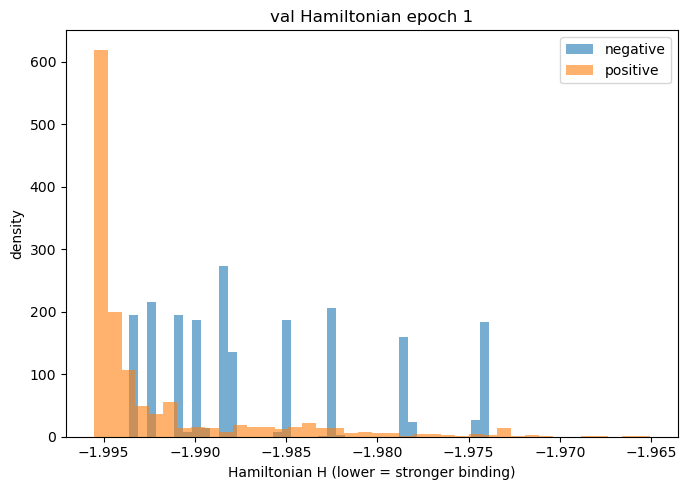

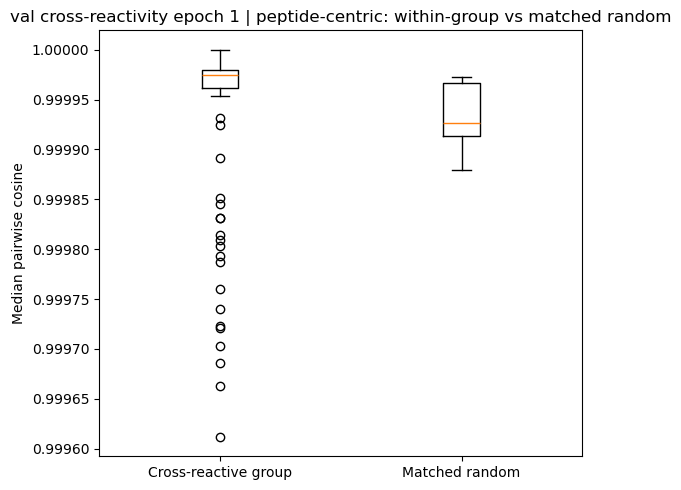

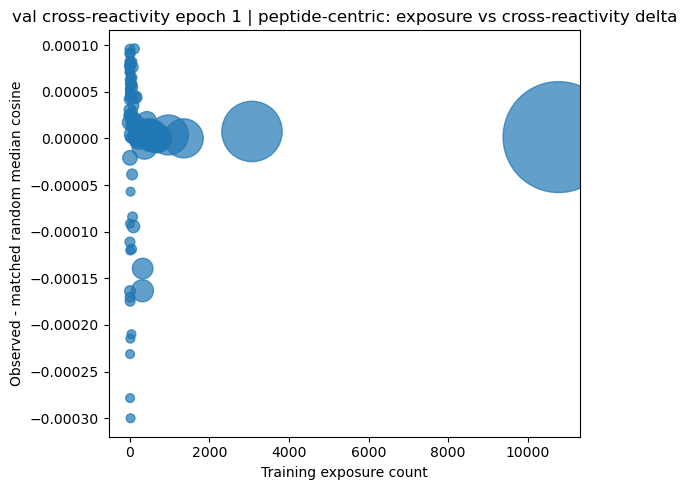

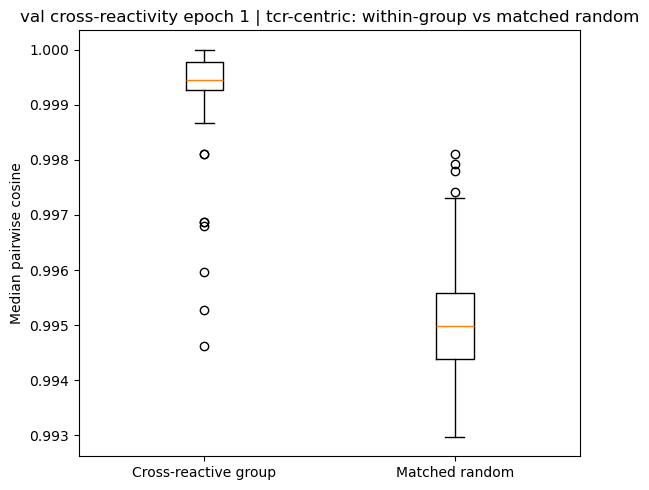

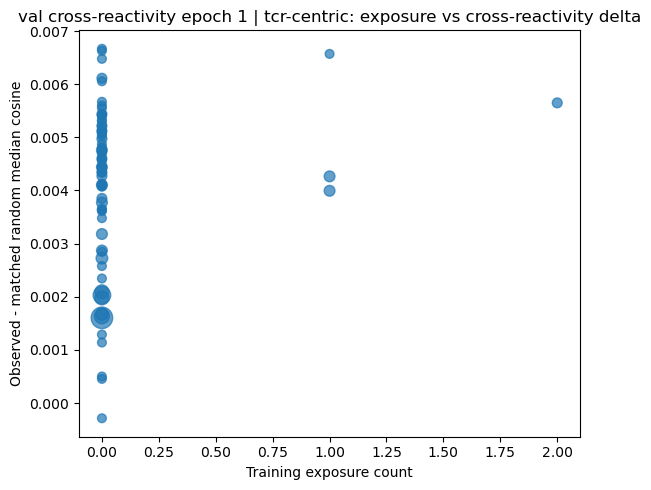

KeyboardInterrupt: 

In [71]:
all_results = []
best_result = None
best_score = -float("inf")  # tracking val_auroc (higher is better)

for i, cfg in enumerate(search_space, 1):
    print(f"\n===== VICReg Hamiltonian run {i}/{len(search_space)} =====")
    print(cfg)

    result = run_baseline_experiment(
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        rL=cfg["rL"],
        rD=cfg["rD"],
        d=cfg["d"],
        alpha=1.0,    # Hamiltonian invariance weight
        beta=25.0,    # VICReg variance weight
        delta=1.0,    # VICReg covariance weight
        lr_tcr=cfg["lr_tcr"],
        lr_pmhc=cfg["lr_pmhc"],
        weight_decay=cfg["weight_decay"],
        num_epochs=20,
        patience=7,
    )

    val_auroc = result["best_state"]["val_metrics"]["auroc"]
    all_results.append((cfg, val_auroc, result))

    if val_auroc > best_score:
        best_score = val_auroc
        best_result = result

print("\nBest val AUROC:", best_result["best_state"]["val_metrics"]["auroc"])
print("Best config:", best_result["best_state"]["config"])


In [36]:
# save the best model
best_save_path = checkpoints_dir / "best_baseline_vicreg_hamiltonian_model.pt"
#best_save_path = checkpoints_dir / "best_baseline_projection_model.pt"

best_checkpoint = {
    "tcr_projection_state_dict": best_result["tcr_projection"].state_dict(),
    "pmhc_projection_state_dict": best_result["pmhc_projection"].state_dict(),
    "best_config": best_result["best_state"]["config"],
    "best_threshold": best_result["best_state"]["threshold"],
    "best_val_metrics": best_result["best_state"]["val_metrics"],
    "history": best_result["history"],
    "best_epoch": best_result["best_state"]["epoch"],
}

torch.save(best_checkpoint, best_save_path)

print(f"Best model saved to {best_save_path}")

Best model saved to /home/natasha/multimodal_model/models/checkpoints/best_baseline_vicreg_hamiltonian_model.pt


In [37]:
# save lightweight summary of HPO runs

hpo_summary = []

for cfg, val_auprc, result in all_results:
    hpo_summary.append({
        "config": cfg,
        "val_auprc": result["best_state"]["val_metrics"]["auprc"],
        "val_auroc": result["best_state"]["val_metrics"]["auroc"],
        "val_f1": result["best_state"]["val_metrics"]["f1"],
        "threshold": result["best_state"]["threshold"],
        "best_epoch": result["best_state"]["epoch"],
    })

torch.save(hpo_summary, checkpoints_dir / "baseline_hpo_summary_hamiltonian.pt")
print(f"HPO summary saved to {checkpoints_dir / 'baseline_hpo_summary_hamiltonian.pt'}")

hpo_df = pd.DataFrame([
    {
        **entry["config"],
        "val_auprc": entry["val_auprc"],
        "val_auroc": entry["val_auroc"],
        "val_f1": entry["val_f1"],
        "threshold": entry["threshold"],
        "best_epoch": entry["best_epoch"],
    }
    for entry in hpo_summary
])

hpo_df.to_csv(checkpoints_dir / "baseline_hpo_summary_hamiltonian.csv", index=False)
hpo_df

HPO summary saved to /home/natasha/multimodal_model/models/checkpoints/baseline_hpo_summary_hamiltonian.pt


,rL,rD,d,lr_tcr,lr_pmhc,weight_decay,val_auprc,val_auroc,val_f1,threshold,best_epoch
0,8,16,128,0.0001,0.0001,0.01,0.505398,0.39526,0.660326,1.414192,6


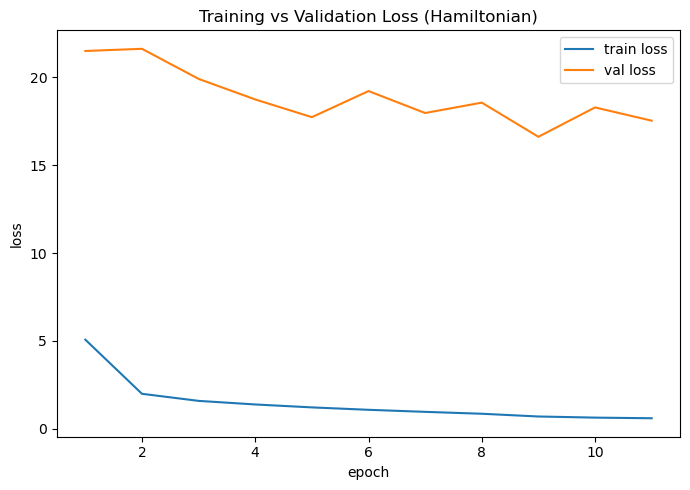

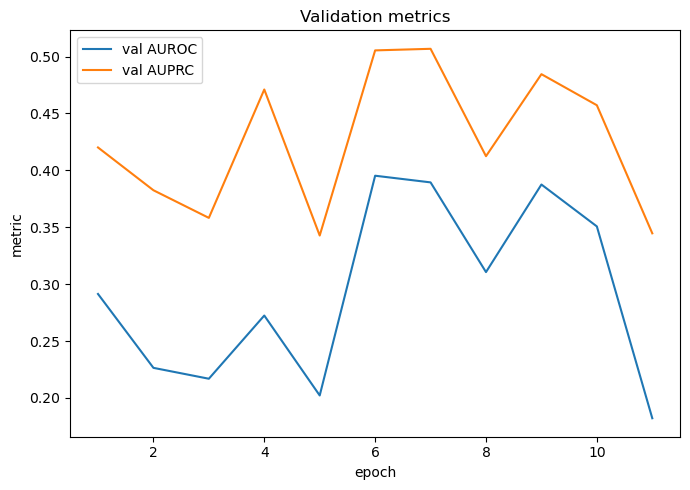

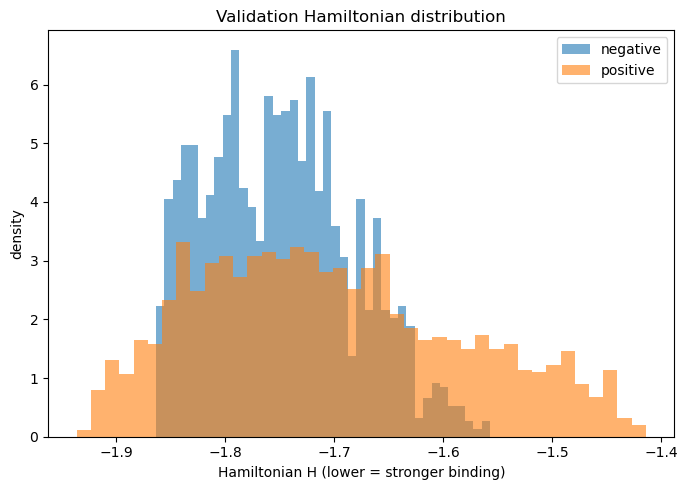

Best validation threshold: 1.4141921997070312
Best validation loss: 19.20970089730578
Validation metrics: {'auroc': 0.3952602880658436, 'auprc': 0.5053984652818353, 'val_loss': 19.20970089730578, 'threshold': 1.4141921997070312, 'f1': 0.6603260869565217, 'accuracy': 0.49290060851926976, 'precision': 0.49290060851926976, 'recall': 1.0}


In [38]:
best_val = best_result["best_state"]["val_outputs"]
best_threshold = best_result["best_state"]["threshold"]

plot_training_history(best_result["history"])
#plot_score_histogram(best_val["scores"], best_val["labels"], title="Validation score distribution (Hamiltonian)")
plot_H_histogram(best_val["H"], best_val["labels"], title="Validation Hamiltonian distribution")

print("Best validation threshold:", best_threshold)
print("Best validation loss:", best_result["best_state"]["val_loss"])
print("Validation metrics:", best_result["best_state"]["val_metrics"])


g) Evaluate on test using best validation threshold

In [39]:
# use evaluation selected threshold on test

@torch.no_grad()
def evaluate_test_with_fixed_threshold(loader, tcr_projection, pmhc_projection, threshold, device, eps=1e-8):
    out = evaluate_baseline_loader(
        loader=loader,
        tcr_projection=tcr_projection,
        pmhc_projection=pmhc_projection,
        device=device,
        eps=eps,
    )

    scores = out["scores"]
    labels = out["labels"]
    preds = (scores >= threshold).astype(int)

    test_metrics = {
        "auroc": roc_auc_score(labels, scores),
        "auprc": average_precision_score(labels, scores),
        "f1": f1_score(labels, preds, zero_division=0),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds),
    }

    out["test_metrics"] = test_metrics
    out["preds"] = preds
    return out

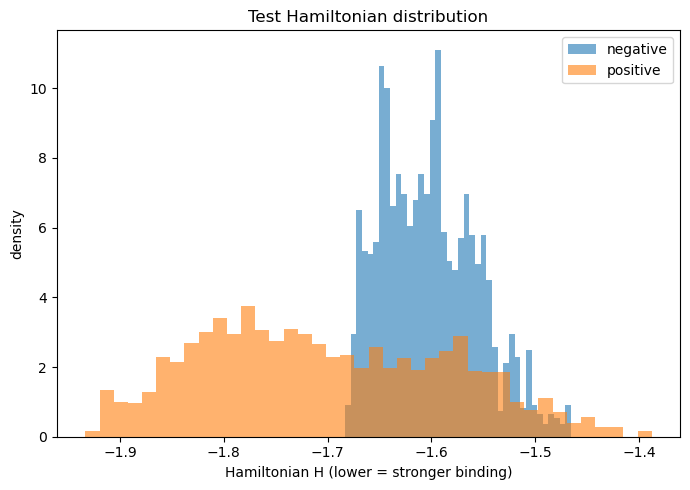

Test metrics: {'auroc': 0.7597842575618698, 'auprc': 0.8519000554763065, 'f1': 0.684698852020758, 'accuracy': 0.5205643232902917, 'precision': 0.5211874551113239, 'recall': 0.9977085242896425, 'confusion_matrix': array([[   0, 2000],
       [   5, 2177]])}
Test confusion matrix:
 [[   0 2000]
 [   5 2177]]


In [40]:
test_out = evaluate_test_with_fixed_threshold(
    loader=test_loader,
    tcr_projection=best_result["tcr_projection"],
    pmhc_projection=best_result["pmhc_projection"],
    threshold=best_threshold,
    device=device,
)

#plot_score_histogram(test_out["scores"], test_out["labels"], title="Test score distribution (Hamiltonian)")
plot_H_histogram(test_out["H"], test_out["labels"], title="Test Hamiltonian distribution")

print("Test metrics:", test_out["test_metrics"])
print("Test confusion matrix:\n", test_out["test_metrics"]["confusion_matrix"])
